# Just the bar plot code for the cosine similarity things

In [67]:
# gloabl imports
import yaml
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from matplotlib.ticker import ScalarFormatter


# Local imports
sys.path.append('../src')
from detection import *
from ml_model import *
import utils


In [4]:
plt.rcParams.update({
    # Figure size - ICML typically uses two-column format
    'figure.figsize': (3.25, 2.5),  # Single column width
    # 'figure.figsize': (6.75, 2.5),  # Double column width
    
    # Font sizes
    'font.size': 10,           # Base font size
    'axes.labelsize': 11,      # X and Y labels
    'axes.titlesize': 11,      # Title
    'xtick.labelsize': 9,      # X tick labels
    'ytick.labelsize': 9,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    
    # Font family
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Use LaTeX for text rendering (optional but recommended)
    'text.usetex': False,  # Set to True if you have LaTeX installed
    
    # Line widths
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Ticks
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    
    # Save settings
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # PDF is preferred for publications
})



In [85]:
similarity_dict = {
    "steeve1_act1": [ 0.006630653981119394],
    "steeve1_act1_paraphrased": [0.00493138562887907],
    "steeve1_act2": [0.0002187100617447868],
    "steeve1_act2_paraphrased": [0.0005456974031403661],
    "steeve2_act1": [-0.0004955294425599277],
    "steeve2_act1_paraphrased": [ -0.0004413667193148285],
    "steeve2_act2": [0.0036342451348900795],
    "steeve2_act2_paraphrased": [ 0.00247229658998549]
}

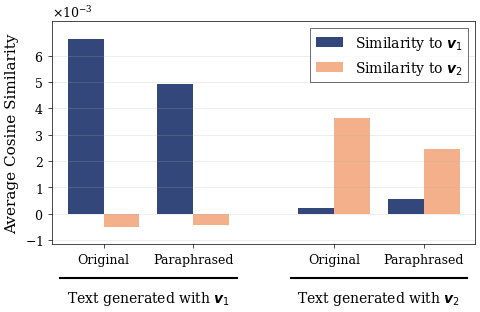

In [86]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

# prepare grouped averages and plot grouped bar chart by category (steeve1 vs steeve2)
keys = list(similarity_dict.keys())
avg_similarities = [np.mean(similarity_dict[k]) for k in keys]

categories = ['Original', 'Paraphrased', 
              'Original', 'Paraphrased']
steeve1_vals = avg_similarities[0:4]
steeve2_vals = avg_similarities[4:8]

colors_palette = [utils.batlow_categorical_colors[i] for i in [0, 4, 4, 6]]

# Create positions for the bars
# We want: [group1_cat1, group1_cat2, gap, group2_cat1, group2_cat2]
group_gap = 0.5
bar_width = 0.35
group_width = 2 * bar_width + bar_width/2  # space for 2 bars per category

# Positions for each category
x_positions = np.array([0, group_width, 
                        group_width*2 + group_gap, 
                        group_width*3 + group_gap])

fig, ax = plt.subplots(figsize=(5, 3))

# Plot bars
bars1 = ax.bar(x_positions - bar_width/2, steeve1_vals, bar_width, 
               label='Similarity to $\\boldsymbol{v}_1$', color=colors_palette[0], alpha=0.8)
bars2 = ax.bar(x_positions + bar_width/2, steeve2_vals, bar_width, 
               label='Similarity to $\\boldsymbol{v}_2$', color=colors_palette[1], alpha=0.8)

# Set category labels
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, fontsize=9)

# Add group labels and brackets
# Group 1: Text generated with steeve1
group1_center = (x_positions[0] + x_positions[1]) / 2
group1_left = x_positions[0] - bar_width/2 - 0.25
group1_right = x_positions[1] + bar_width/2 + 0.25

ax.text(group1_center, -0.2, 'Text generated with $\\boldsymbol{v}_1$', 
        ha='center', va='top', fontsize=10,
        transform=ax.get_xaxis_transform())
ax.plot([group1_left, group1_right], [-0.15, -0.15], 
        color='black', linewidth=1.5, transform=ax.get_xaxis_transform(), 
        clip_on=False)

# Group 2: Text generated with steeve2
group2_center = (x_positions[2] + x_positions[3]) / 2
group2_left = x_positions[2] - bar_width/2 - 0.25
group2_right = x_positions[3] + bar_width/2 + 0.25

ax.text(group2_center, -0.2, 'Text generated with $\\boldsymbol{v}_2$', 
        ha='center', va='top', fontsize=10,
        transform=ax.get_xaxis_transform())
ax.plot([group2_left, group2_right], [-0.15, -0.15], 
        color='black', linewidth=1.5, transform=ax.get_xaxis_transform(), 
        clip_on=False)

# Labels and styling
ax.set_ylabel('Average Cosine Similarity', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Adjust x-limits to show all bars clearly
ax.set_xlim(-0.5, x_positions[-1] + 0.5)

# ####### Adjust y-limits and ticks
y_min = min(min(steeve1_vals), min(steeve2_vals))
y_max = max(max(steeve1_vals), max(steeve2_vals))

# Round y_max to 1 decimal place (or 2 if you prefer)
# y_max_rounded = np.ceil(y_max * 1000) / 1000  # rounds up to 1 decimal

ax.set_ylim(y_min - 0.1*y_max, y_max + 0.1*y_max)
# ax.set_yticks([y_min, 0, y_max])
ax.set_yticks(np.array([-1, 0, 1, 2, 3, 4, 5, 6])*0.001)
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))  # 1 decimal
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0e}'))

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 4)) 
ax.yaxis.set_major_formatter(formatter)


# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

plt.savefig("similarity_bar_chart.pdf", dpi=300, bbox_inches='tight')
plt.show()